# Experiments

We implement the algorithm presented in the corresponding paper (Algorithm 1), measure its efficiency and compare it with the computation of Choquet integral on mass functions.

- Evidence functions: proposed algorithm
- Mass functions: classical Choquet integral using $\sum_{B\in\mathcal{S}(m)} m(B)\times \min_{\omega\in B} u(a(\omega))$

In [1]:
from random import random
import matplotlib.pyplot as plt
from time import time

### Generation of random data

The frame of discernment is $\Omega=\{0, \dots, n-1\}$.

- Evidence functions $M : 2 ^\Omega\to\mathbb{I}(\mathbb{R}_+)$ are implemented as list of pairs $(B, [x_B,y_B])$ where $B\subseteq\Omega$ is a focal element (`set`) and $x_B\leq y_B$ its min/max evidence (`float`)
- Mass functions $m : 2 ^\Omega\to[0,1]]$ are implemented as list of pairs $(B, x)$ where $B\subseteq\Omega$ is a focal element (`set`) and $x$ its mass (`float`).
- Utility functions $u : \Omega\to\mathbb{R}$ are implemented as dictionnaries.

In [2]:
def random_set(fod_size: int):
    """Random non-empty subset of {0, ..., fod_size-1}"""
    B = set()
    while B == set():
        for i in range(fod_size):
            if random() > 0.5:
                B.add(i)
    return B

def random_evidence_function(fod_size: int, nb_focal_els: int, max_value : float = 100):
    """Random evidence function with nb_focal_els focal elements on {0, ..., fod_size-1}"""
    M = []
    for _ in range(nb_focal_els):
        x = random()*max_value
        y = min(max_value, x+random()*max_value)
        M.append((random_set(fod_size), (x, y)))
    return M

def random_mass_function(fod_size: int, nb_focal_els: int):
    """Random mass function with nb_focal_els focal elements on {0, ..., fod_size-1}"""
    m = []
    total = 0
    for _ in range(nb_focal_els):
        x = random()
        total += x
        m.append((random_set(fod_size), x))
    return [(B, mB/total) for B, mB in m]


def mass2evidence(m):
    """Yield the certain evidence function from a mass function"""
    return [(B, (mB, mB)) for B, mB in m]

def random_utility_function(fod_size: int, max_value : float = 100):
    """Random utility function u : {0, ..., fod_size} -> [0, max_value)"""
    u = {}
    for i in range(fod_size):
        u[i] = random()*max_value
    return u

## MinEU computation

- The Choquet integral (`CEU`) is suited for mass functions
- The proposed algorithm (`minEU`) is suited for evidence functions. Its optional parameters are:
  - `return_f`: set to `True` to return the whole sequence of values
  - `return_t`: set to `True` to return the computation time of each part of the algorithm

In [3]:

def CEU(m, u):
    """Choquet integration of the utility function u w.r.t the mass function m"""
    return sum([mB * u[min(B, key=lambda w: u[w])] for (B, mB) in m])

def minEU(M, u, return_f=False, return_t=False):
    """Minimum expected utility of the utility function u w.r.t. the evidence function M"""

    t0 = time()

    # Sort the fod
    fod = sorted(u.keys(), key = lambda i: u[i])

    t1 = time()

    # Initialize the L- and L+ values
    Linf = {w: 0 for w in fod}
    Lsup = {w: 0 for w in fod}
    for (B, (MinfB, MsupB)) in M:
        w = min(B, key=lambda i: u[i])
        Linf[w] += MinfB
        Lsup[w] += MsupB

    t2 = time()
    
    # Initialize the y and z values (computation of f(0))
    y = sum([Linf[w]*u[w] for w in fod])
    z = sum(Linf)

    t3 = time()

    # 1. Compute the sequence [f(0), ..., f(n)] (return_f=True)
    if return_f:
        f = [y / z]
        for i, w in enumerate(fod):
            y = y + (Lsup[w] - Linf[w]) * u[w]
            z = z + Lsup[w] - Linf[w]
            f.append(y/z)
        if return_t:
            t4 = time()
            return f, (t1-t0, t2-t1, t3-t2, t4-t3)
        else:
            return f
    
    # 2. Compute f(i) until i^* is reached (return_f=False)
    last_f = y/z
    for i, w in enumerate(fod):
        y = y + (Lsup[w] - Linf[w]) * u[w]
        z = z + Lsup[w] - Linf[w]
        f = y/z
        if f > last_f:
            if return_t:
                t4 = time()
                return last_f, (t1-t0, t2-t1, t3-t2, t4-t3)
            else:
                return last_f
        last_f = f
    if return_t:
        t4 = time()
        return f, (t1-t0, t2-t1, t3-t2, t4-t3)
    return f


## Example

In [4]:
# FOD size
n = 100

# Number of focal elements
s = 1000

# Evidence function
M = random_evidence_function(n, s)

# Utility function
u = random_utility_function(n)

# Minimum expected utility of u w.r.t. M
print("minEU:", minEU(M, u))
print("sequence:", minEU(M, u, return_f=True))



minEU: 4.476728749771785
sequence: [21.119813176338983, 5.251690967101659, 4.563420246627136, 4.488311894135589, 4.476728749771785, 4.526611309827998, 4.543033814821751, 4.556376746185557, 4.565137501598905, 4.5740901289831095, 4.5740901289831095, 4.588578166882147, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047213, 4.59547943047

## Computation time of the algorithm's parts

The initialization of $\lambda^+_i$ and $\lambda^-_i$ values is the most computationally intensive part. Other parts might be treated as negligible. 

3.47, 357.36, 359.89, 360.00, 

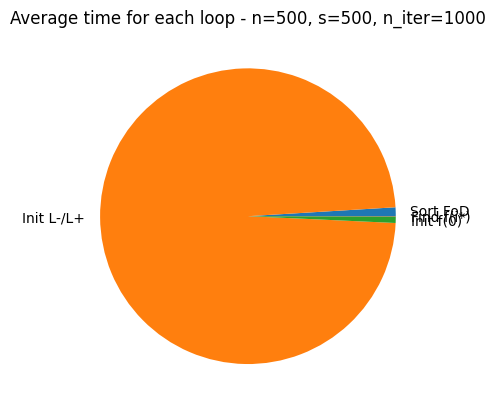

In [5]:
# FOD size
n = 500

# Number of focal elements
s = 500

# Number of iterations
N_ITER = 1000

# Average times
T = [0,0,0,0]


for _ in range(N_ITER):
    # Generate random data
    M = random_evidence_function(n, s)
    u = random_utility_function(n)

    # Compute minEU
    _, t = minEU(M, u, return_f=False, return_t=True)

    # Store computation times
    for i in range(n):
        T = [T[i] + t[i] for i in range(4)]

# Compute the average
for i in range(4):
    T[i] /= N_ITER

# Tikz print (angles of a pie diagram)
normT = [360*Ti/sum(T) for Ti in T]
a = 0
for i in range(4):
    a = normT[i]+a
    print(f"{a:.2f}", end=", ")

# Plot
plt.pie(T, labels=["Sort FoD", "Init L-/L+", "Init f(0)", "Find f(i*)"])
plt.title(f"Average time for each loop - n={n}, s={s}, n_iter={N_ITER}")
plt.show()



## Rank where the minEU is reached

Algorithm iterates for $i=0$ to $i=i^*+1$, where $f(i^*)$ is the minEU value. This rank is usually a low value (it depends on the structure of the set of focal elements).

2/107, 3/353, 4/250, 5/132, 6/63, 7/44, 8/22, 9/18, 10/6, 11/4, 12/1


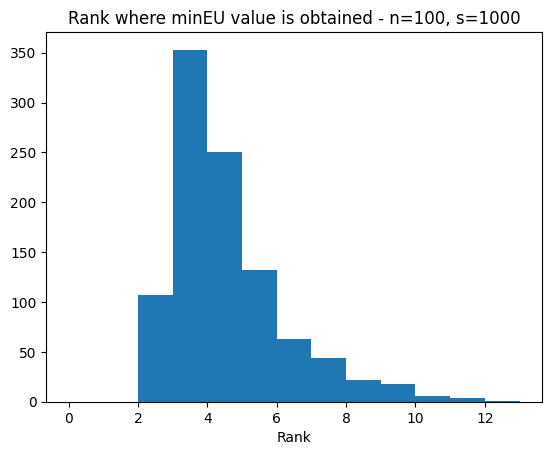

In [6]:
# FOD size
n = 100

# Number of focal elements
s = 1000

# Number of iterations
N_ITER = 1000

# Rank of minEU
I = []
res = {i: 0 for i in range(n+1)}


for _ in range(N_ITER):
    M = random_evidence_function(n, s)
    u = random_utility_function(n)
    f = minEU(M, u, return_f=True)
    rank = min(range(n), key=lambda i: f[i])
    I.append(rank)
    res[rank] += 1

# Tikz foreach print
print(", ".join([f"{i}/{nb}" for i, nb in res.items() if nb>0]))

# Histogram
plt.hist(I, bins=range(max(I)+2))
plt.title(f"Rank where minEU value is obtained - n={n}, s={s}")
plt.xlabel("Rank")
plt.ylabel("")
plt.show()



# Comparison with the Choquet integral

### 1. Fixed number of focal elements, variable frame of discernment

Using 
- $s=100$
- $n \in \{50, 100, \dots, 500\}$.

50/0.00024/0.00017, 100/0.00033/0.00032, 150/0.00055/0.00050, 200/0.00083/0.00069, 250/0.00086/0.00083, 300/0.00105/0.00096, 350/0.00122/0.00109, 400/0.00138/0.00123, 450/0.00159/0.00133, 500/0.00178/0.00164


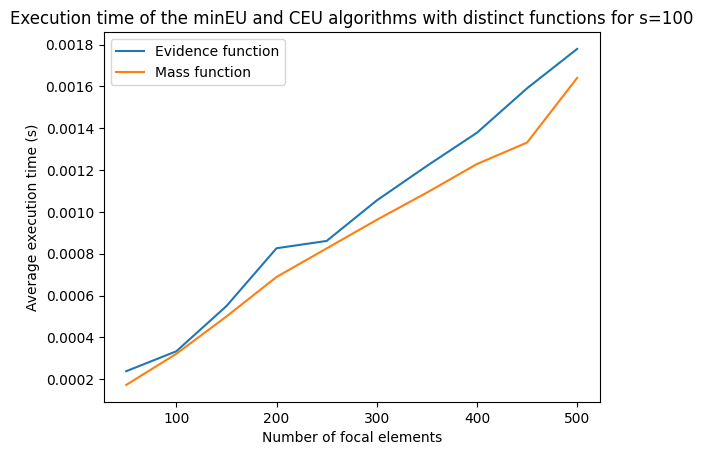

In [7]:
# max FOD size
N = 500

# Number of focal elements
S = 100

# Number of iterations
N_ITER = 500

# data
xs = []
results = []

for n in range(N//10, N+1, N//10):
    xs.append(n)
    results.append([0,0])

    # Generate the data (not timed)
    u = [random_utility_function(n) for _ in range(N_ITER)]
    M = [random_evidence_function(n,S) for _ in range(N_ITER)]
    m = [random_mass_function(n,S) for _ in range(N_ITER)]

    # Time for minEU
    t0 = time()
    for i in range(N_ITER):
        f = minEU(M[i], u[i])
    t = time() - t0
    results[-1][0] = t / N_ITER

    # Time for CEU
    t0 = time()
    for i in range(N_ITER):
        f = CEU(m[i], u[i])
    t = time() - t0
    results[-1][1] = t / N_ITER

# Formatted string for tikz's foreach syntax
print(", ".join([f"{x}/{results[i][0]:.5f}/{results[i][1]:.5f}" for i, x in enumerate(xs)]))

# Plot
plt.plot(xs, results)
plt.title(f"Execution time of the minEU and CEU algorithms with distinct functions for s={S}")
plt.xlabel("Number of focal elements")
plt.ylabel("Average execution time (s)")
plt.legend(["Evidence function", "Mass function"])
plt.show()


### 2. Variable number of focal elements, fixed frame of discernment

Using:
- $s=\in \{50, 100, \dots, 500\}$,
- $n=100$

50/0.00021/0.00017, 100/0.00037/0.00035, 150/0.00058/0.00048, 200/0.00071/0.00067, 250/0.00088/0.00084, 300/0.00107/0.00095, 350/0.00121/0.00106, 400/0.00139/0.00130, 450/0.00150/0.00145, 500/0.00172/0.00160


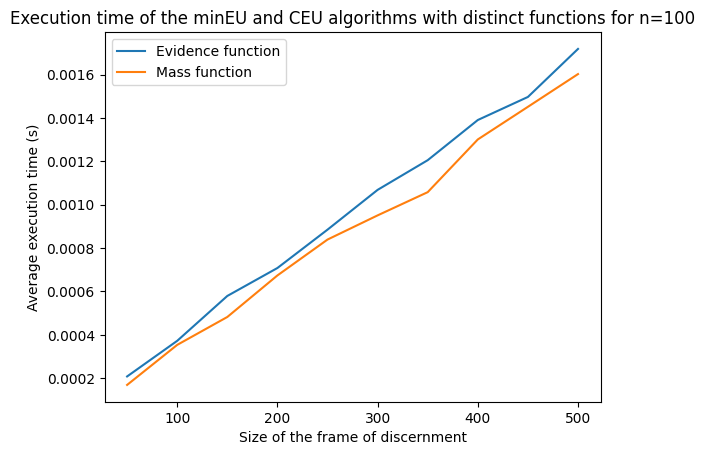

In [8]:
# FOD size
N = 100

# max number of focal elements
S = 500

# Number of iterations
N_ITER = 500

# data
xs = []
results = []

for s in range(S//10, S+1, S//10):
    xs.append(s)
    results.append([0,0])

    # Generate the data (not timed)
    u = [random_utility_function(N) for _ in range(N_ITER)]
    M = [random_evidence_function(N,s) for _ in range(N_ITER)]
    m = [random_mass_function(N,s) for _ in range(N_ITER)]

    # Time for minEU
    t0 = time()
    for i in range(N_ITER):
        f = minEU(M[i], u[i])
    t = time() - t0
    results[-1][0] = t / N_ITER

    # Time for CEU
    t0 = time()
    for i in range(N_ITER):
        f = CEU(m[i], u[i])
    t = time() - t0
    results[-1][1] = t / N_ITER

# Formatted string for tikz's foreach syntax
print(", ".join([f"{x}/{results[i][0]:.5f}/{results[i][1]:.5f}" for i, x in enumerate(xs)]))

# Plot
plt.plot(xs, results)
plt.title(f"Execution time of the minEU and CEU algorithms with distinct functions for n={N}")
plt.xlabel("Size of the frame of discernment")
plt.ylabel("Average execution time (s)")
plt.legend(["Evidence function", "Mass function"])
plt.show()